[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/jinming99/learn-ml-by-building/blob/main/Lecture%202%20KNN/02-KNN-Zero-Shot-Matching.ipynb)

# Lecture 2 case study: from similarity to learned compatibility

The k-nearest-neighbor method ranks stored examples under a chosen representation and scoring rule:

`query → filter eligible candidates → score → rank → keep the top k ranks (including exact ties)`

This case study keeps the ranking procedure fixed and examines how the scoring rule shapes a zero-shot teammate-matching system. See the [main Lecture 2 notebook](02-KNN.ipynb) for the complete k-NN lesson.

By the end, you should be able to:

- explain how the representation and scoring rule determine a k-NN ranking;
- translate a human preference into a logical constraint and hinge loss; and
- distinguish a distance or dissimilarity from a compatibility cost.

## 1. Formulate the matching problem

You are the fixed query. For each candidate $i$, the desired outcome is

$$y_i=\mathbb{1}\{\text{student }i\text{ works well with me}\}$$

This outcome has not been observed yet, so the system ranks eligible candidates using assumptions we design. The executable case study uses ten synthetic profiles with the same eight-axis schema as the class survey.

| Design choice | Choice in this case study |
|---|---|
| Eligibility | Exclude students already working solo |
| Representation | Eight numerical survey axes on $[-1,1]$ |
| Scoring rule | Start with standard distance, then revise it |

The categorical `team_status` field is an eligibility rule; it is separate from the numerical `solo_collaborative` feature. Filter ineligible candidates before ranking.

> k-NN does not decide what compatibility means. It returns the nearest eligible candidates under the representation and scoring rule we choose.

In [1]:
# @title Colab Setup
from pathlib import Path
import json
import os
import subprocess
import sys

if "google.colab" in sys.modules:
    repo_root = Path("/content/learn-ml-by-building")
    if not repo_root.exists():
        subprocess.run(
            ["git", "clone", "https://github.com/jinming99/learn-ml-by-building.git", str(repo_root)],
            check=True,
        )
    lecture_dir = repo_root / "Lecture 2 KNN"
    os.chdir(lecture_dir)
else:
    lecture_candidates = [Path.cwd(), Path.cwd() / "Lecture 2 KNN"]
    lecture_dir = next(
        (path.resolve() for path in lecture_candidates if (path / "project-matchmaker").exists()),
        None,
    )
    if lecture_dir is None:
        raise FileNotFoundError("Run this notebook from the repository or Lecture 2 directory.")
    repo_root = lecture_dir.parent

for module_path in (lecture_dir, repo_root):
    if str(module_path) not in sys.path:
        sys.path.insert(0, str(module_path))

import numpy as np
import pandas as pd
from IPython.display import display
from sklearn.metrics import pairwise_distances

from knn_zero_shot_figures import (
    plot_compatibility,
    plot_metric_learning,
    plot_metric_rank_matrix,
    set_case_study_style,
)

set_case_study_style()

with (lecture_dir / "project-matchmaker/student_data_sample.json").open() as file:
    dataset = json.load(file)

features = dataset["dimensions"]
students = pd.DataFrame(dataset["students"])[features + ["team_status"]].copy()
del dataset  # retain only the fields needed for this anonymized case study
X = students[features].to_numpy(dtype=float)
students["student_id"] = [f"Student {index + 1:02d}" for index in range(len(students))]

# Keep one query and one neighborhood size throughout the case study.
QUERY_INDEX = 1
QUERY_LABEL = "You (anonymized profile)"
K = 3

if students.loc[QUERY_INDEX, "team_status"] == "solo":
    raise ValueError("Choose a query profile that is seeking a team.")

print(
    f"Loaded {len(students)} synthetic profiles with {len(features)} features. "
    f"Query: {QUERY_LABEL}."
)

Loaded 10 synthetic profiles with 8 features. Query: You (anonymized profile).


## 2. Compare standard scoring rules

All eight extracted features lie on a nominal $[-1,1]$ range. For two profiles $\mathbf{x}$ and $\mathbf{z}$, let $\Delta_j=x_j-z_j$.

| Rule | Definition | A small value means… |
|---|---:|---|
| Euclidean | $\sqrt{\sum_j \Delta_j^2}$ | gaps are small overall; large gaps count more |
| Manhattan | $\sum_j |\Delta_j|$ | total coordinate-wise disagreement is small |
| Cosine dissimilarity | $1-\frac{\mathbf{x}^{\top}\mathbf{z}}{\lVert\mathbf{x}\rVert_2\lVert\mathbf{z}\rVert_2}$ | vectors point in the same direction |
| Chebyshev | $\max_j |\Delta_j|$ | no single feature is badly mismatched |

Cosine dissimilarity emphasizes direction rather than magnitude. It is undefined for a zero vector and is not generally a mathematical metric. The rank matrix compares the actual eight-feature rankings without suggesting that a two-dimensional projection preserves the scores.

In [2]:
METRICS = {
    "Euclidean": "euclidean",
    "Manhattan": "manhattan",
    "Cosine dissimilarity": "cosine",
    "Chebyshev": "chebyshev",
}


def top_k_rank_table(X, students, query_index, k, metrics):
    """Return tie-aware candidate ranks under several scoring rules."""
    eligible = students["team_status"].ne("solo").to_numpy()
    eligible[query_index] = False
    candidate_index = np.flatnonzero(eligible)
    rank_columns = {}

    for metric_name, metric_code in metrics.items():
        distances = pairwise_distances(X[[query_index]], X, metric=metric_code)[0]
        ranks = pd.Series(
            distances[candidate_index],
            index=students.loc[candidate_index, "student_id"],
        ).rank(method="min")  # exact ties receive the same rank
        rank_columns[metric_name] = ranks[ranks <= k]

    table = pd.DataFrame(rank_columns)
    order = pd.DataFrame(
        {
            "best_rank": table.min(axis=1),
            "mean_rank": table.fillna(k + 1).mean(axis=1),
        }
    ).sort_values(["best_rank", "mean_rank"])
    return table.loc[order.index]


metric_ranks = top_k_rank_table(X, students, QUERY_INDEX, K, METRICS)

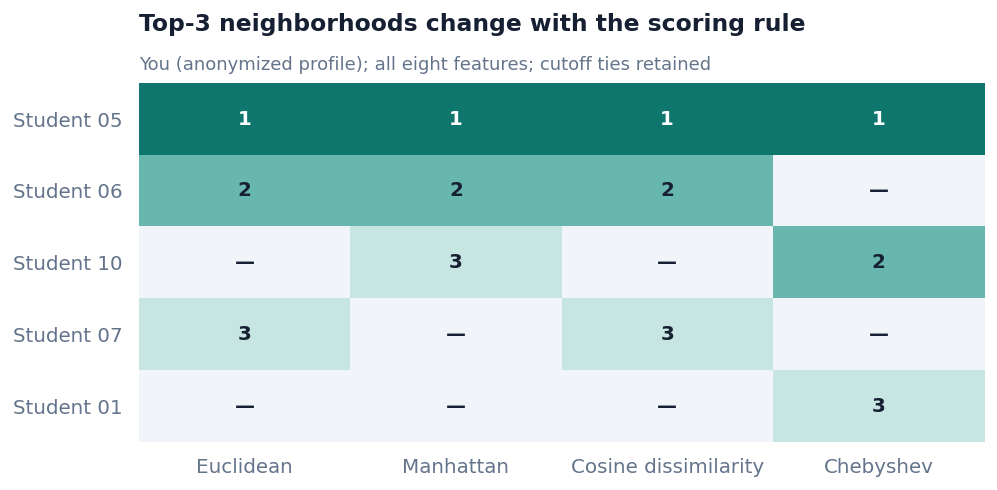

In [3]:
plot_metric_rank_matrix(
    metric_ranks,
    QUERY_LABEL,
    K,
)

Student 05 appears in every neighborhood, and Student 06 appears under Euclidean, Manhattan, and cosine dissimilarity. The boundary changes across rules: Student 07 appears under Euclidean and cosine dissimilarity, Student 10 under Manhattan and Chebyshev, and Student 01 only under Chebyshev. The code retains exact cutoff ties if they occur.

**Zero-shot limitation:** without the outcomes $y_i$, these comparisons cannot tell us which rule predicts collaboration best. The scoring rule and cutoff-tie policy remain testable modeling choices.

## 3. Learn a weighted distance from feedback

Distance learning begins with a concrete failure: we prefer $A$ to $B$, but the current distance ranks $B$ closer. Let $\mathbf{x}_{\mathrm{me}}=(5,5)$, $\mathbf{x}_A=(5,9)$, and $\mathbf{x}_B=(7,6)$.

| Weighted squared distance | $A$ | $B$ | Closer candidate |
|---|---:|---:|---|
| Equal weights $(1,1)$ | $16$ | $5$ | $B$ |
| Learned weights $(4,1)$ | $16$ | $17$ | $A$ |

The human preference first becomes the logical condition

$$d_{\mathbf{w}}(\mathbf{x}_{\mathrm{me}},\mathbf{x}_A)^2<d_{\mathbf{w}}(\mathbf{x}_{\mathrm{me}},\mathbf{x}_B)^2.$$

A diagonal weighted squared distance gives the model parameters that can satisfy this ordering:

$$d_{\mathbf{w}}(\mathbf{x},\mathbf{z})^2=\sum_j w_j(x_j-z_j)^2,\qquad w_j\geq 0.$$

The loss uses squared distances. The corresponding $d_{\mathbf{w}}$ is a metric when every weight is strictly positive; allowing a zero weight collapses that coordinate and gives a pseudometric.

**From a preference to a training loss.** After teams collaborate, a triplet $(a,p,n)$ records that anchor $a$ prefers positive example $p$ over negative example $n$. With margin $m>0$, the desired condition is

$$d_{\mathbf{w}}(a,p)^2+m\leq d_{\mathbf{w}}(a,n)^2.$$

Define $g_{a,p,n}(\mathbf{w})=d_{\mathbf{w}}(a,n)^2-d_{\mathbf{w}}(a,p)^2$. The condition is $g_{a,p,n}(\mathbf{w})\geq m$, which becomes the hinge loss

$$\mathcal{L}(\mathbf{w})=\max\bigl(0,m-g_{a,p,n}(\mathbf{w})\bigr).$$

**Why the maximum matters.** Without the outer maximum, minimizing $m-g$ keeps rewarding an already-correct triplet for making the gap arbitrarily large. Clipping the loss at zero once the margin is met prevents this reward hacking and focuses learning on violated preferences.

The three rows below are **simulated feedback**, not claims about real students. For one triplet, the positive example must be closer on at least one available feature for nonnegative diagonal weights to reverse the ranking. This check is necessary but does not guarantee that every triplet can be satisfied jointly.

In [4]:
feedback = pd.DataFrame(
    {
        "anchor": [3, 1, 0],
        "positive": [5, 8, 1],
        "negative": [9, 6, 6],
        "salient_axis": [
            "Structured / exploratory",
            "Theory / implementation",
            "Plan first / iterate quickly",
        ],
    },
    index=["T1", "T2", "T3"],
)
feedback.index.name = "triplet"
triplets = feedback[["anchor", "positive", "negative"]].to_numpy(dtype=int)

feedback_view = feedback.copy()
for column in ["anchor", "positive", "negative"]:
    feedback_view[column] = feedback_view[column].map(students["student_id"])
    feedback_view[column] = feedback_view[column].replace(
        students.loc[QUERY_INDEX, "student_id"], QUERY_LABEL
    )

display(feedback_view)

,anchor,positive,negative,salient_axis
triplet,,,,
T1,Student 04,Student 06,Student 10,Structured / exploratory
T2,You (anonymized profile),Student 09,Student 07,Theory / implementation
T3,Student 01,You (anonymized profile),Student 07,Plan first / iterate quickly


In [5]:
def fit_diagonal_metric(
    X,
    triplets,
    learning_rate=0.2,
    margin=0.05,
    max_epochs=20,
):
    """Fit nonnegative feature weights with a projected hinge-loss update."""
    anchor, positive, negative = np.asarray(triplets).T

    # evidence @ weights = g_{a,p,n}(w) = d_w(a, n)^2 - d_w(a, p)^2
    evidence = (
        (X[anchor] - X[negative]) ** 2
        - (X[anchor] - X[positive]) ** 2
    )
    weights = np.ones(X.shape[1])
    history = [evidence @ weights]

    for _ in range(max_epochs):
        violated = history[-1] < margin
        if not violated.any():
            break

        # Subgradient step on the sum of violated hinge losses.
        weights = np.maximum(
            0.0,
            weights + learning_rate * evidence[violated].sum(axis=0),
        )
        history.append(evidence @ weights)

    if np.any(history[-1] < margin):
        raise RuntimeError(
            "Feedback was not separated. Revisit the triplets or representation "
            "before increasing max_epochs."
        )

    return weights, np.vstack(history)


MARGIN = 0.05
learned_weights, gap_history = fit_diagonal_metric(
    X,
    triplets,
    margin=MARGIN,
    max_epochs=20,
)
epochs_used = len(gap_history) - 1

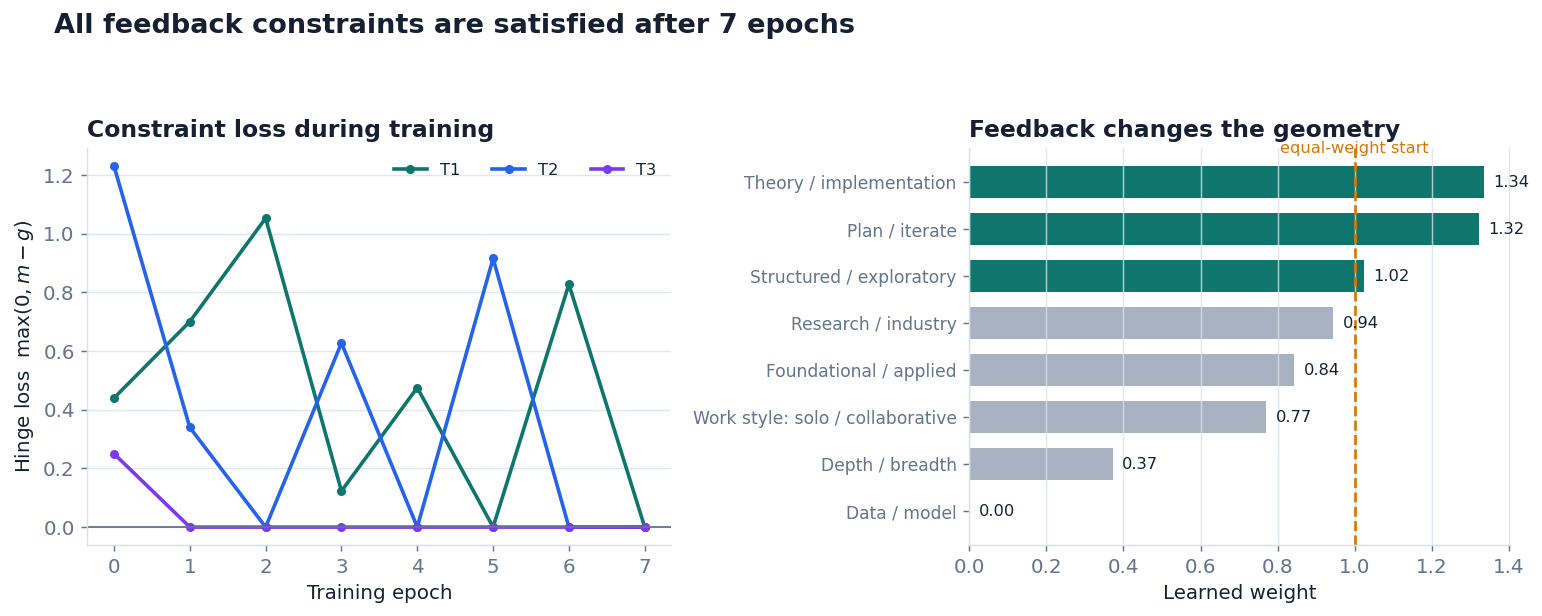

In [6]:
feature_labels = {
    "theory_implementation": "Theory / implementation",
    "research_industry": "Research / industry",
    "structured_exploratory": "Structured / exploratory",
    "solo_collaborative": "Work style: solo / collaborative",
    "depth_breadth": "Depth / breadth",
    "plan_iterate": "Plan / iterate",
    "data_model": "Data / model",
    "foundational_applied": "Foundational / applied",
}

plot_metric_learning(
    gap_history,
    feedback.index,
    features,
    feature_labels,
    learned_weights,
    MARGIN,
    epochs_used,
)

The plotted hinge losses reach zero once all three margins are satisfied. The largest weights correspond to the three simulated feedback signals: structured/exploratory, theory/implementation, and plan/iterate.

This is successful **optimization**, not evidence of generalization. A real learner needs more feedback, a held-out evaluation, and checks for noisy or contradictory triplets.

## 4. Design a compatibility cost for role coverage

A weighted Euclidean metric can learn **which similarities matter**, but it still makes zero gap ideal on every feature. A teammate-matching hypothesis may instead encode:

- **alignment** in working approach, with target gap $0$; and
- **role coverage** across technical perspectives, with a moderate target gap $\tau>0$.

Rewarding the largest possible gap is too strong: opposite extremes are not automatically useful partners. For $\Delta_j=|x_j-z_j|$, use

$$L_{\text{align}}=\operatorname{mean}_{j\in S}\Delta_j^2,$$

$$L_{\text{cover}}=\operatorname{mean}_{j\in C}(\Delta_j-\tau)^2,$$

$$C(\mathbf{x},\mathbf{z})=\alpha L_{\text{align}}+(1-\alpha)L_{\text{cover}}.$$

Here $\tau=0.6$ and $\alpha=0.5$ are visible, testable assumptions. Lower is better. $C$ is a **compatibility cost**, not a mathematical distance: on a role-coverage feature, zero gap can receive a penalty, so identity of indiscernibles fails.

In [7]:
ALIGNMENT_FEATURES = ["structured_exploratory"]
COVERAGE_FEATURES = ["theory_implementation", "data_model"]
TARGET_GAP = 0.6
ALIGN_WEIGHT = 0.5


def rank_compatible_partners(
    students,
    query_index,
    alignment_features,
    coverage_features,
    target_gap,
    align_weight,
):
    """Rank eligible partners by alignment and coverage targets."""
    eligible = students["team_status"].ne("solo")
    candidates = students.loc[eligible].drop(index=query_index).copy()
    query = students.loc[query_index]

    alignment_gaps = (
        candidates[alignment_features] - query[alignment_features]
    ).abs()
    coverage_gaps = (
        candidates[coverage_features] - query[coverage_features]
    ).abs()

    result = candidates[["student_id"]].copy()
    result["alignment_cost"] = alignment_gaps.pow(2).mean(axis=1)
    result["coverage_cost"] = (
        coverage_gaps - target_gap
    ).pow(2).mean(axis=1)
    result["compatibility_cost"] = (
        align_weight * result["alignment_cost"]
        + (1 - align_weight) * result["coverage_cost"]
    )
    return result.sort_values(["compatibility_cost", "student_id"])


compatibility = rank_compatible_partners(
    students,
    QUERY_INDEX,
    ALIGNMENT_FEATURES,
    COVERAGE_FEATURES,
    TARGET_GAP,
    ALIGN_WEIGHT,
)

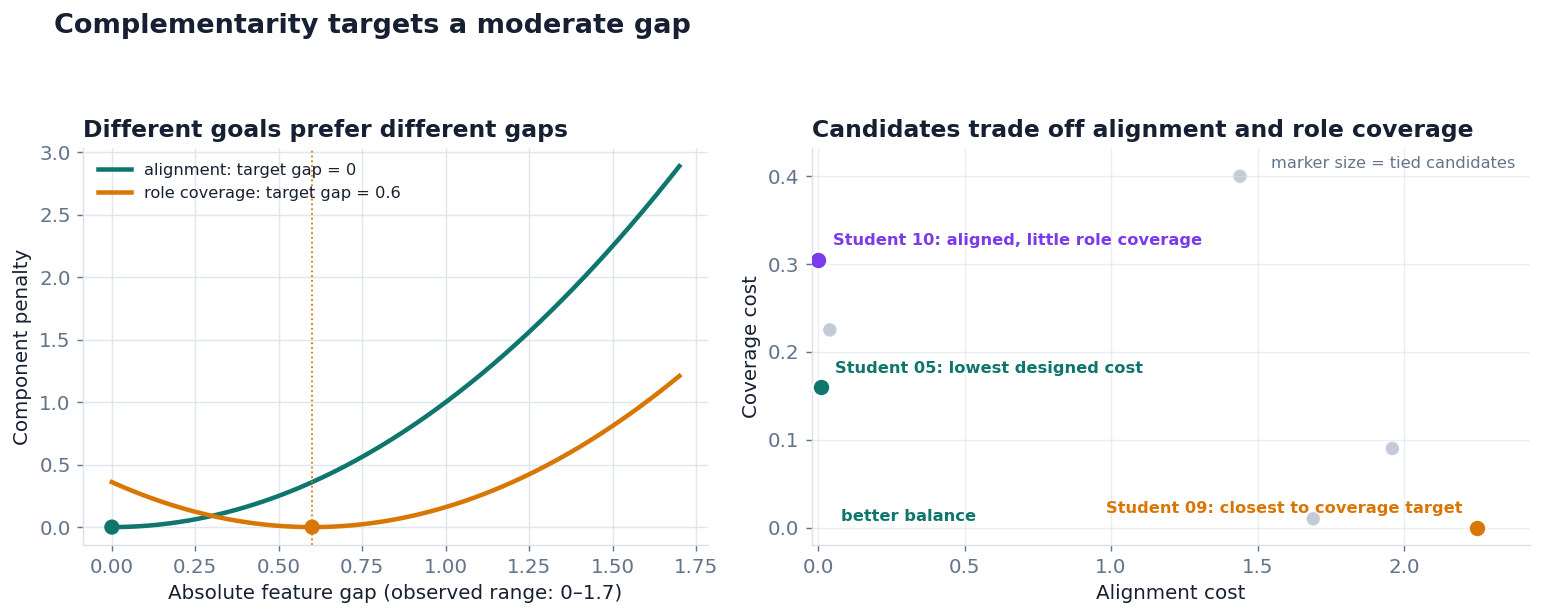

In [8]:
plot_compatibility(
    compatibility,
    students,
    QUERY_INDEX,
    ALIGNMENT_FEATURES,
    COVERAGE_FEATURES,
    TARGET_GAP,
)

The lowest-cost candidate under this designed score sits near the lower-left: low alignment cost and low coverage-target cost. The annotated contrasts show why optimizing either component alone can produce a higher combined cost under this design.

This score ranks partners for one query. It does **not** optimize the composition of a whole team or establish that these assumptions improve real collaboration.

## 5. Key takeaways

1. **k-NN ranks under a chosen geometry.** Representation, scoring rule, eligibility, and tie policy all affect the neighbors.
2. **Feedback can change that geometry.** A preference becomes a logical constraint and then a hinge loss the machine can optimize.
3. **Coverage can require a nonzero target gap.** That creates a compatibility cost rather than an ordinary distance.

Evaluate preference satisfaction on held-out anchors, teams, or future cohorts, then use acceptance and collaboration outcomes as evidence. When the system fails, inspect the problem definition, survey, extraction, eligibility, geometry, and outcome measurement rather than assuming that $k$ is the only cause.